# Detector Model Comparison
**Tsviki Y. Hirsh**

Side-by-side comparison of simulated $\\Delta x$ residuals for different detector models
against the experimental in-focus data.

**Best parameters from sweep:** `image_intensifier_gain`, `gain=10000`, `blob=0.7`

## Workflow
For each model config: `trace_rays` → `empirun run_suffix` → `nea associate` → plot $\\Delta x$

## 1. Imports & Paths

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from itertools import product

import lumacam
from lumacam import Lens, VerbosityLevel

from empirun.groupby import run_suffix
from empirun.cli import get_default_empir_paths, resolve_empir_paths

import neutron_event_analyzer as nea

# ── Paths ────────────────────────────────────────────────────────────────────
# Archive that contains SimPhotons/ (Geant4 outputs) AND will receive tpx3Files/
ARCHIVE     = Path('/work/nuclear/PTB/archive/openbeam_ptb_hs')

# parameterSettings JSON used for EMPIR reconstruction
PARAMS_FILE = Path('/work/nuclear/PTB/data/PTB2024/parameterSettings_out_of_focus.json')

# Experimental associated data (already processed from real measurement)
EXP_CSV     = Path("/work/nuclear/PTB/data/PTB2024") / 'out_of_focus' / 'AssociatedResults' / 'associated_data.csv'

# ── EMPIR binaries ────────────────────────────────────────────────────────────
_raw_empir = os.environ.get('EMPIR_PATH')
EMPIR_DIRS = (
    resolve_empir_paths(_raw_empir)
    if _raw_empir
    else resolve_empir_paths(os.pathsep.join(get_default_empir_paths()))
)
print(f'EMPIR search dirs: {[str(p) for p in EMPIR_DIRS]}')

EMPIR search dirs: ['/work/Programs/lumacam_measurementcontrol']


## 2. Load Experimental Data

In [3]:
df_exp = pd.read_csv(EXP_CSV)#.query("0.25e-6<`px/tof`<0.8e-6")
print(f'Experimental: {len(df_exp):,} rows   columns: {list(df_exp.columns[:8])} ...')
df_exp.head(3)

Experimental: 572,805 rows   columns: ['px/x', 'px/y', 'px/toa', 'px/tot', 'px/tof', 'ph/id', 'ph/x', 'ph/y'] ...


,px/x,px/y,px/toa,px/tot,px/tof,ph/id,ph/x,ph/y,ph/toa,ph/cog,ev/id,ev/x,ev/y,ev/toa,ev/n,ev/psd,ev/cog,ph/n
0,80.0,175.0,0.001456,19.0,9.625000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,80.0,174.0,0.001456,3.0,1.062500e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,53.0,102.0,0.001458,86.0,3.046875e-07,1.0,53.93,102.32,0.001458,4.315837e-07,21903.0,70.45,110.08,0.001458,2.0,7.812500e-10,0.0,8


<Axes: ylabel='Frequency'>

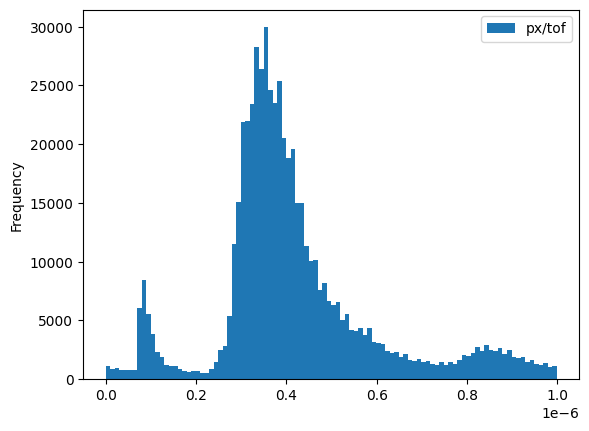

In [4]:
df_exp.plot.hist(y="px/tof",bins=100)

<Axes: xlabel='px/x', ylabel='px/y'>

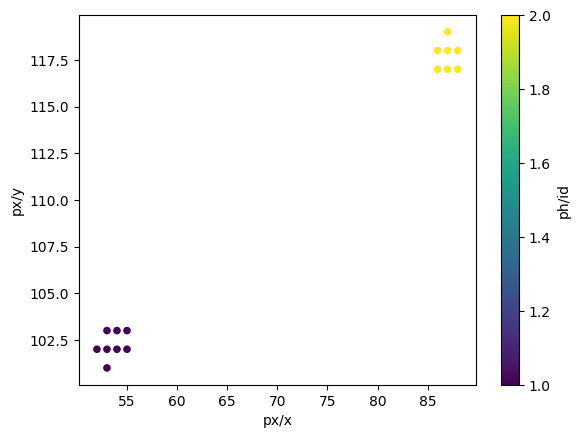

In [5]:
df_exp.query("`px/toa`<0.001503").plot.scatter(x="px/x",y="px/y",c="ph/id")

In [6]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [7]:
dd = df_exp.query("`px/toa`<0.001503 and `px/x`<70")

In [8]:

df_exp["ph/Δtoa"] = df_exp["px/toa"] - df_exp["ph/toa"]
df_exp["ev/Δtoa"] = df_exp["ph/toa"] - df_exp["ev/toa"]

df_exp["ph/Δx"] = df_exp["px/x"] - df_exp["ph/x"]
df_exp["ev/Δx"] = df_exp["ph/x"] - df_exp["ev/x"]
df_exp["ph/Δy"] = df_exp["px/y"] - df_exp["ph/y"]
df_exp["ev/Δy"] = df_exp["ph/y"] - df_exp["ev/y"]

<Axes: ylabel='Frequency'>

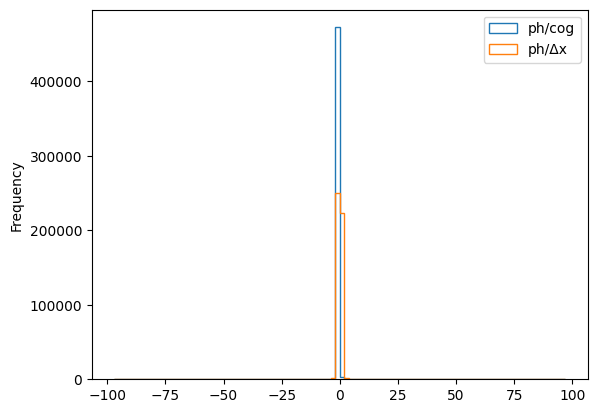

In [9]:
df_exp.plot.hist(y=["ph/cog","ph/Δx"],bins=100,logy=False,histtype="step")

## 3. Setup Lens

The `Lens` loads `SimPhotons/*.csv` from the archive at init time.
Ray tracing through the optical model is done once per `trace_rays()` call;
only the detector saturation parameters (`gain`, `blob`, `deadtime`) change
between sweep iterations.

In [12]:
lens = Lens(
    archive=str(ARCHIVE),
    kind='nikkor_58mm',
    # zfine=12.75,
    verbosity=VerbosityLevel.BASIC,
)
print(f'Loaded {len(lens.data):,} simulated photons from {ARCHIVE}/SimPhotons/')

Loading simulation data:   0%|          | 0/39 [00:00<?, ?it/s]

Loaded 220,176 simulated photons from /work/nuclear/PTB/archive/openbeam_ptb_hs/SimPhotons/


## 4. Model Configurations

Each dict needs `"name"` (used as the subfolder suffix) and `"detector_model"`.
All other keys are passed as kwargs to `lens.trace_rays()`.

Edit or extend this list to explore different detector physics.

In [13]:
MODEL_CONFIGS = [
    # ── Sweep decay_time (scintillator/phosphor decay constant, ns) ───────────
    # Fixed: gain=50000, blob=0.4, deadtime=600 (best from previous sweep)
    {"name": "blob_0.3_gain_10000_deadtime_200",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.3, "deadtime": 200, "decay_time":  60},
    {"name": "blob_0.3_gain_10000_deadtime_50",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.3, "deadtime": 50, "decay_time":  60},
    {"name": "blob_0.3_gain_10000_decay_100",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.3, "deadtime": 600, "decay_time":  100},
    {"name": "blob_0.3_gain_1000",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.3, "deadtime": 600, "decay_time":  60},
    {"name": "blob_0.3_gain_10000", "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.3, "deadtime": 600, "decay_time": 60},
    {"name": "blob_0.3_gain_100000", "detector_model": "image_intensifier_gain",
     "gain": 100000, "blob": 0.3, "deadtime": 600, "decay_time": 60},
    
    {"name": "blob_0.7_gain_10000_deadtime_200",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.7, "deadtime": 200, "decay_time":  60},
    {"name": "blob_0.7_gain_10000_deadtime_50",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.7, "deadtime": 50, "decay_time":  60},
    {"name": "blob_0.7_gain_10000_decay_100",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.7, "deadtime": 600, "decay_time":  100},
    {"name": "blob_0.7_gain_1000",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.7, "deadtime": 600, "decay_time":  60},
    {"name": "blob_0.7_gain_10000", "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.7, "deadtime": 600, "decay_time": 60},
    {"name": "blob_0.7_gain_100000", "detector_model": "image_intensifier_gain",
     "gain": 100000, "blob": 0.7, "deadtime": 600, "decay_time": 60},
    
    {"name": "blob_0.5_gain_10000_deadtime_200",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.5, "deadtime": 200, "decay_time":  60},
    {"name": "blob_0.5_gain_10000_deadtime_50",  "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.5, "deadtime": 50, "decay_time":  60},
    {"name": "blob_0.5_gain_10000_decay_100",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.5, "deadtime": 600, "decay_time":  100},
    {"name": "blob_0.5_gain_1000",  "detector_model": "image_intensifier_gain",
     "gain": 1000, "blob": 0.5, "deadtime": 600, "decay_time":  60},
    {"name": "blob_0.5_gain_10000", "detector_model": "image_intensifier_gain",
     "gain": 10000, "blob": 0.5, "deadtime": 600, "decay_time": 60},
    {"name": "blob_0.5_gain_100000", "detector_model": "image_intensifier_gain",
     "gain": 100000, "blob": 0.5, "deadtime": 600, "decay_time": 60},
    
]


import math
print(f'{len(MODEL_CONFIGS)} model configurations:')
for cfg in MODEL_CONFIGS:
    kw = {k: v for k, v in cfg.items() if k not in ('name', 'detector_model')}
    print(f"  {cfg['name']:14s}  model={cfg['detector_model']:28s}  {kw}")

18 model configurations:
  blob_0.3_gain_10000_deadtime_200  model=image_intensifier_gain        {'gain': 10000, 'blob': 0.3, 'deadtime': 200, 'decay_time': 60}
  blob_0.3_gain_10000_deadtime_50  model=image_intensifier_gain        {'gain': 10000, 'blob': 0.3, 'deadtime': 50, 'decay_time': 60}
  blob_0.3_gain_10000_decay_100  model=image_intensifier_gain        {'gain': 1000, 'blob': 0.3, 'deadtime': 600, 'decay_time': 100}
  blob_0.3_gain_1000  model=image_intensifier_gain        {'gain': 1000, 'blob': 0.3, 'deadtime': 600, 'decay_time': 60}
  blob_0.3_gain_10000  model=image_intensifier_gain        {'gain': 10000, 'blob': 0.3, 'deadtime': 600, 'decay_time': 60}
  blob_0.3_gain_100000  model=image_intensifier_gain        {'gain': 100000, 'blob': 0.3, 'deadtime': 600, 'decay_time': 60}
  blob_0.7_gain_10000_deadtime_200  model=image_intensifier_gain        {'gain': 10000, 'blob': 0.7, 'deadtime': 200, 'decay_time': 60}
  blob_0.7_gain_10000_deadtime_50  model=image_intensifier_gain    

## 5. Run Models

For each config the loop:
1. Pops `name` and `detector_model` from the dict, passes the rest as kwargs to `trace_rays`
2. Runs `empirun run_suffix` using `name` as the subfolder
3. Runs NEA association

Already-processed subfolders are loaded from disk (skip logic).

In [14]:
results = {}   # name -> associated DataFrame

for cfg in MODEL_CONFIGS:
    cfg       = cfg.copy()
    name      = cfg.pop('name')
    det_model = cfg.pop('detector_model')
    decay_time = cfg.pop('decay_time', 100.0)   # ns — pop so it doesn't go into **trace_kw
    trace_kw  = cfg                              # remaining: gain, blob, deadtime, …

    out_csv = ARCHIVE / name / 'AssociatedResults' / 'associated_data.csv'
    print(f'\n{"="*60}\n  {name}  [{det_model}]  decay_time={decay_time} ns\n{"="*60}')

    # ── Skip if already done ──────────────────────────────────────
    if out_csv.exists():
        print(f'  [skip] {out_csv}')
        results[name] = pd.read_csv(out_csv)
        continue

    # ── Step 1: Trace → Saturate → Write tpx3 ────────────────────
    print(f'  [1/3] trace_rays  decay_time={decay_time}  {trace_kw}')
    lens.trace_rays(
        detector_model=det_model,
        decay_time=float(decay_time),
        seed=42,
        verbosity=VerbosityLevel.QUIET,
        progress_bar=False,
        **trace_kw,
    )

    # ── Step 2: EMPIR pipeline ────────────────────────────────────
    print(f'  [2/3] empirun  suffix={name}')
    ok = run_suffix(
        data_path=ARCHIVE,
        params_path=PARAMS_FILE,
        empir_search_dirs=EMPIR_DIRS,
        suffix=name,
        export_pixels=True,
        export_photons=True,
        export_events=True,
        run_event2image=False,
        verbosity=0,
    )
    if not ok:
        print(f'  [WARN] empirun failed')
        continue

    # ── Step 3: NEA association ───────────────────────────────────
    print(f'  [3/3] nea-assoc')
    analyser = nea.Analyse(
        data_folder=str(ARCHIVE / name),
        settings=str(PARAMS_FILE),
        verbosity=0,
    )
    analyser.load(verbosity=0)
    analyser.associate(method='empir', suffix=name, verbosity=1)

    results[name] = analyser.associated_df
    print(f'  Done: {len(results[name]):,} rows')

print(f'\nCompleted {len(results)}/{len(MODEL_CONFIGS)} models.')


  blob_0.3_gain_10000_deadtime_200  [image_intensifier_gain]  decay_time=60 ns
  [1/3] trace_rays  decay_time=60  {'gain': 10000, 'blob': 0.3, 'deadtime': 200}
  [2/3] empirun  suffix=blob_0.3_gain_10000_deadtime_200
  [3/3] nea-assoc


Associating pixels to photons:   0%|          | 0/23684 [00:00<?, ?it/s]

Pixel-Photon: 80,059/144,813 pixels (55.3%)
              23,508/23,684 photons (99.3%)


Associating photons to events:   0%|          | 0/16661 [00:00<?, ?it/s]

Photon-Event: 23,601/23,684 photons matched (99.6%)
             16,659/16,661 events matched (100.0%)
Saved 144,813 rows to /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.3_gain_10000_deadtime_200/AssociatedResults/associated_data_blob_0.3_gain_10000_deadtime_200.csv (16.10 MB)
Saved to: /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.3_gain_10000_deadtime_200/AssociatedResults/associated_data_blob_0.3_gain_10000_deadtime_200.csv
  Done: 144,813 rows

  blob_0.3_gain_10000_deadtime_50  [image_intensifier_gain]  decay_time=60 ns
  [1/3] trace_rays  decay_time=60  {'gain': 10000, 'blob': 0.3, 'deadtime': 50}
  [2/3] empirun  suffix=blob_0.3_gain_10000_deadtime_50
  [3/3] nea-assoc


...

Photon-Event: 53,297/54,162 photons matched (98.4%)
             31,390/31,438 events matched (99.8%)
Saved 740,079 rows to /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.5_gain_10000/AssociatedResults/associated_data_blob_0.5_gain_10000.csv (63.95 MB)
Saved to: /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.5_gain_10000/AssociatedResults/associated_data_blob_0.5_gain_10000.csv
  Done: 740,079 rows

  blob_0.5_gain_100000  [image_intensifier_gain]  decay_time=60 ns
  [1/3] trace_rays  decay_time=60  {'gain': 100000, 'blob': 0.5, 'deadtime': 600}
  [2/3] empirun  suffix=blob_0.5_gain_100000
  [3/3] nea-assoc


Associating pixels to photons:   0%|          | 0/53603 [00:00<?, ?it/s]

Pixel-Photon: 218,141/740,079 pixels (29.5%)
              52,771/53,603 photons (98.4%)


Associating photons to events:   0%|          | 0/31407 [00:00<?, ?it/s]

Photon-Event: 52,747/53,603 photons matched (98.4%)
             31,359/31,407 events matched (99.8%)
Saved 740,079 rows to /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.5_gain_100000/AssociatedResults/associated_data_blob_0.5_gain_100000.csv (63.77 MB)
Saved to: /work/nuclear/PTB/archive/openbeam_ptb_hs/blob_0.5_gain_100000/AssociatedResults/associated_data_blob_0.5_gain_100000.csv
  Done: 740,079 rows

Completed 18/18 models.


## 6. Side-by-Side $\Delta x$ Comparison

In [15]:
def compute_deltas(df):
    """Add Δx columns to a copy of df. Skips missing tier columns gracefully."""
    d = df.copy()
    if 'px/x' in d.columns and 'ph/x' in d.columns:
        d['ph/Δx'] = d['px/x'] - d['ph/x']
    if 'ph/x' in d.columns and 'ev/x' in d.columns:
        d['ev/Δx'] = d['ph/x'] - d['ev/x']
    if 'px/x' in d.columns and 'ev/x' in d.columns:
        d['px/Δx'] = d['px/x'] - d['ev/x']
    return d


def plot_deltas(ax, df, title='', query='', color_offset=0):
    """Plot Δx histograms on a given Axes."""
    d = compute_deltas(df)
    if query:
        d = d.query(query)
    bins = np.arange(-5, 5.05, 0.1)
    cols  = [c for c in ['ph/Δx', 'ev/Δx', 'px/Δx'] if c in d.columns]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    labels = [r'$\Delta x_{ph}$ (px−ph)', r'$\Delta x_{ev}$ (ph−ev)', r'$\Delta x_{px}$ (px−ev)']
    for col, color, label in zip(cols, colors, labels):
        ax.hist(d[col].dropna(), bins=bins, histtype='step',
                linewidth=1.5, color=color, label=label, log=True)
    ax.set_xlim(-5, 5)
    ax.set_xlabel('Δx (pixels)')
    ax.set_ylabel('Counts')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

In [16]:
n_panels = len(results) + 1   # +1 for experiment
n_cols   = min(n_panels, 4)
n_rows   = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.5 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(n_rows, n_cols)

def panel_title(cfg_orig):
    kw = {k: v for k, v in cfg_orig.items() if k not in ('name', 'detector_model')}
    kw_str = '  '.join(f'{k}={v}' for k, v in kw.items())
    return f"{cfg_orig['name']}\n[{cfg_orig['detector_model']}]\n{kw_str}"

# Experiment in slot 0
plot_deltas(axes.flat[0], df_exp, title='EXPERIMENT\n[in_focus]')

# Models in subsequent slots
cfg_by_name = {c['name']: c for c in MODEL_CONFIGS}
for i, name in enumerate(results):
    ax = axes.flat[i + 1]
    title = panel_title(cfg_by_name[name])
    plot_deltas(ax, results[name], title=title)

# Hide any unused axes
for ax in axes.flat[len(results) + 1:]:
    ax.set_visible(False)

fig.suptitle('Detector Model Comparison — $\\Delta x$ Residuals', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ARCHIVE / 'model_comparison_out_of_focus.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {ARCHIVE}/model_comparison.png')

AxisError: axis 4 is out of bounds for array of dimension 0

## 7. Side-by-side: Best Simulation vs Experiment

Pick the best-matching simulation run by minimising the width of `ph/Δx`.

In [22]:
from math import min

ImportError: cannot import name 'min' from 'math' (/root/micromamba/lib/python3.13/lib-dynload/math.cpython-313-x86_64-linux-gnu.so)

In [24]:
# Width metric: IQR of ph/Δx
def iqr_width(df):
    d = compute_deltas(df)
    if 'ph/Δx' not in d.columns:
        return np.inf
    q = d['ph/Δx'].dropna().quantile([0.25, 0.75])
    return float(q[0.75] - q[0.25])

exp_iqr = iqr_width(df_exp)
print(f'Experiment ph/Δx IQR: {exp_iqr:.3f} px')

widths = {sfx: iqr_width(df) for sfx, df in results.items()}
best_sfx = min(widths, key=lambda s: abs(widths[s] - exp_iqr))
print(f'Best match: {best_sfx}  (IQR={widths[best_sfx]:.3f} px, Δ={abs(widths[best_sfx]-exp_iqr):.3f})')

# IQR comparison table
pd.DataFrame([
    {'suffix': s, 'IQR(ph/Δx)': f'{v:.3f}', 'Δ_from_exp': f'{abs(v-exp_iqr):.3f}'}
    for s, v in sorted(widths.items(), key=lambda x: abs(x[1]-exp_iqr))
]).set_index('suffix')

Experiment ph/Δx IQR: 1.040 px


TypeError: min() got an unexpected keyword argument 'key'

In [18]:
best_sfx

NameError: name 'best_sfx' is not defined

In [23]:
d = results[best_sfx]

In [23]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


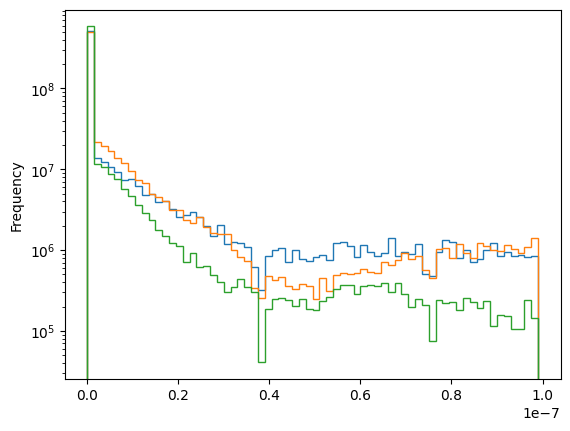

In [26]:
d = results["blob_0.3_gain_10000_deadtime_200"]
(d["ph/toa"] - d["ev/toa"]).plot.hist(density=True,bins=arange(0,1e-7,1.5e-9),histtype="step",ax=gca())
d = results["blob_0.5_gain_10000_deadtime_50"]
(d["ph/toa"] - d["ev/toa"]).plot.hist(density=True,bins=arange(0,1e-7,1.5e-9),histtype="step",ax=gca())
(df_exp["ph/toa"] - df_exp["ev/toa"]).plot.hist(density=True,bins=arange(0,1e-7,1.5e-9),histtype="step",ax=gca())
yscale("log")

<Axes: xlabel='px/x', ylabel='px/y'>

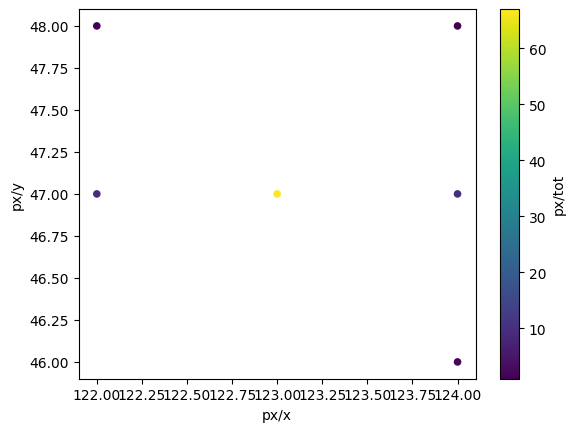

In [28]:
d.query("`ph/id`==2").plot.scatter(x="px/x",y="px/y",c="px/tot")

<Axes: xlabel='px/x', ylabel='px/y'>

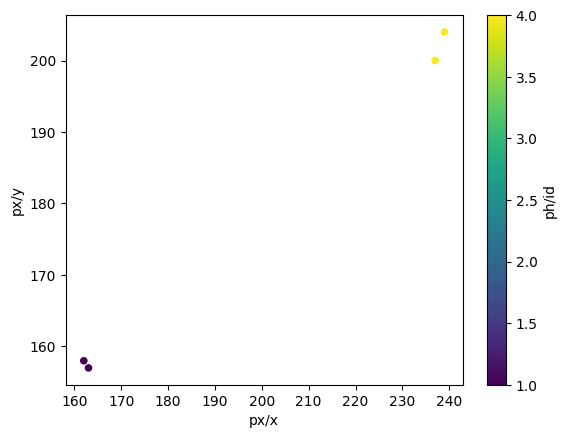

In [29]:
d.head(30).plot.scatter(x="px/x",y="px/y",c="ph/id")

In [30]:
d = results["blob_0.3_gain_100000"]
d["ph/Δtoa"] = d["px/toa"] - d["ph/toa"]
d["ev/Δtoa"] = d["ph/toa"] - d["ev/toa"]
df_exp["ph/Δtoa"] = df_exp["px/toa"] - df_exp["ph/toa"]
df_exp["ev/Δtoa"] = df_exp["ph/toa"] - df_exp["ev/toa"]

d["ph/Δx"] = d["px/x"] - d["ph/x"]
d["ev/Δx"] = d["ph/x"] - d["ev/x"]
df_exp["ph/Δx"] = df_exp["px/x"] - df_exp["ph/x"]
df_exp["ev/Δx"] = df_exp["ph/x"] - df_exp["ev/x"]

<Axes: xlabel='ph/cog', ylabel='ph/Δtoa'>

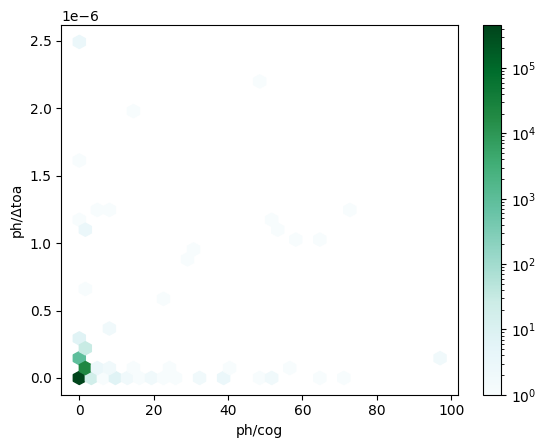

In [31]:
df_exp.plot.hexbin(x="ph/cog",y="ph/Δtoa",bins="log",gridsize=30)

<Axes: xlabel='ev/Δx', ylabel='ph/Δtoa'>

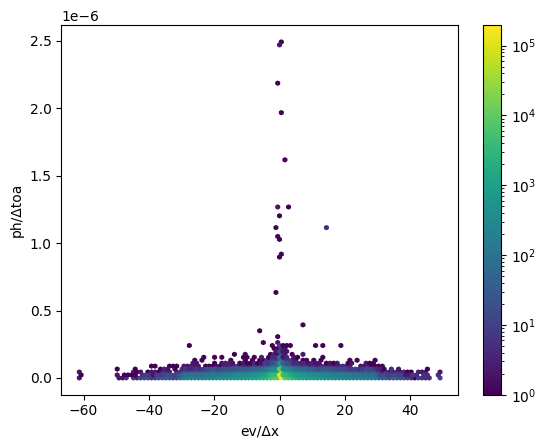

In [34]:
df_exp.plot.hexbin(x="ev/Δx",y="ph/Δtoa",gridsize=100,cmap="viridis",bins="log")

<Axes: xlabel='ph/Δx', ylabel='ph/Δtoa'>

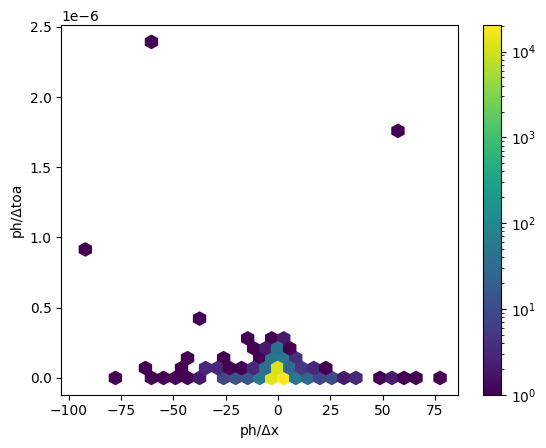

In [35]:
d.dropna(subset="ph/id").plot.hexbin(x="ph/Δx",y="ph/Δtoa",gridsize=30,cmap="viridis",bins="log")

In [89]:
res = {}
counts = {}
res["exp"] = df_exp.head(230000)["ph/n"].value_counts().sort_index().reindex(arange(20))
counts["exp"] = df_exp.dropna()["ph/n"].count()
for key in results:
    res[key] = results[key]["ph/n"].value_counts().sort_index().reindex(arange(20))
    counts[key] = results[key].dropna()["ph/n"].count()

In [88]:
df = pandas.Series(counts)
df

exp                                 474887
blob_0.3_gain_10000_deadtime_200     79756
blob_0.3_gain_10000_deadtime_50      83580
blob_0.3_gain_10000_decay_100        68999
blob_0.3_gain_1000                   79222
blob_0.3_gain_10000                  79592
blob_0.3_gain_100000                 44972
blob_0.7_gain_10000_deadtime_200    255263
blob_0.7_gain_10000_deadtime_50     230657
blob_0.7_gain_10000_decay_100       358317
blob_0.7_gain_1000                  259057
blob_0.7_gain_10000                 240365
blob_0.7_gain_100000                238769
blob_0.5_gain_10000_deadtime_200    232457
blob_0.5_gain_10000_deadtime_50     206564
blob_0.5_gain_10000_decay_100       307988
blob_0.5_gain_1000                  220284
blob_0.5_gain_10000                 222041
blob_0.5_gain_100000                214112
dtype: int64

In [93]:
import pandas
df = pandas.DataFrame(res).T
df = (df.iloc[1:]/df.iloc[0])
df.mean(1).sort_values()

blob_0.3_gain_10000_decay_100       0.632997
blob_0.3_gain_1000                  0.680197
blob_0.3_gain_10000                 0.726518
blob_0.3_gain_10000_deadtime_200    0.740382
blob_0.3_gain_10000_deadtime_50     0.879539
blob_0.3_gain_100000                0.925818
blob_0.5_gain_10000                 2.432488
blob_0.5_gain_100000                2.506994
blob_0.5_gain_10000_deadtime_200    2.523942
blob_0.5_gain_10000_deadtime_50     2.681889
blob_0.5_gain_1000                  3.291532
blob_0.7_gain_100000                3.389909
blob_0.7_gain_10000                 3.435497
blob_0.7_gain_10000_deadtime_200    3.579414
blob_0.5_gain_10000_decay_100       3.757626
blob_0.7_gain_10000_deadtime_50     3.885583
blob_0.7_gain_10000_decay_100       7.331731
blob_0.7_gain_1000                  8.829082
dtype: float64

<Axes: ylabel='Frequency'>

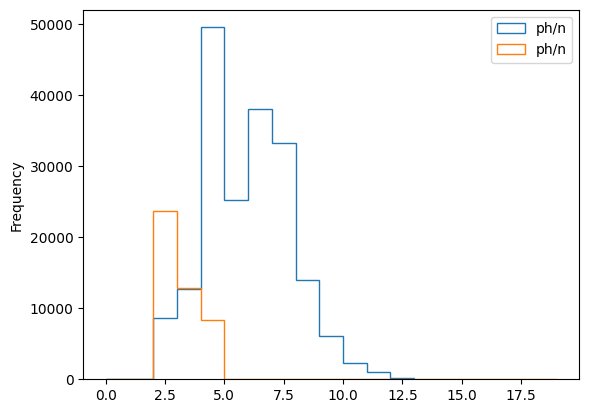

In [94]:
df_exp.head(230000).dropna().plot.hist(y="ph/n",density=False,bins=arange(14),histtype="step",ax=gca())
d = results["blob_0.3_gain_100000"].dropna()
d.plot.hist(y="ph/n",density=False,bins=arange(20),histtype="step",ax=gca())
# yscale("log")

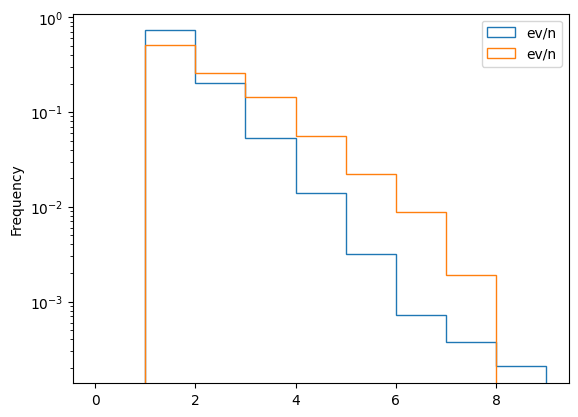

In [67]:
df_exp.dropna().plot.hist(y="ev/n",density=True,bins=arange(10),histtype="step",ax=gca())
d = results["blob_0.3_gain_1000"].dropna()
d.dropna(subset="ph/id").plot.hist(y="ev/n",density=True,bins=arange(10),histtype="step",ax=gca())
yscale("log")

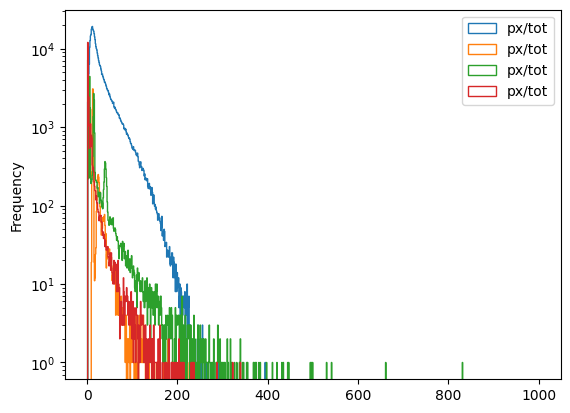

In [85]:
df_exp.dropna().plot.hist(y="px/tot",bins=arange(1000),histtype="step",ax=gca())
d = results["blob_0.3_gain_1000"].dropna(subset="ph/id")
d.plot.hist(y="px/tot",bins=arange(1000),histtype="step",ax=gca())
d = results["blob_0.7_gain_10000"].dropna(subset="ph/id")
d.plot.hist(y="px/tot",bins=arange(1000),histtype="step",ax=gca())
d = results["blob_1.2_gain_10000"].dropna(subset="ph/id")
d.plot.hist(y="px/tot",bins=arange(1000),histtype="step",ax=gca())
yscale("log")

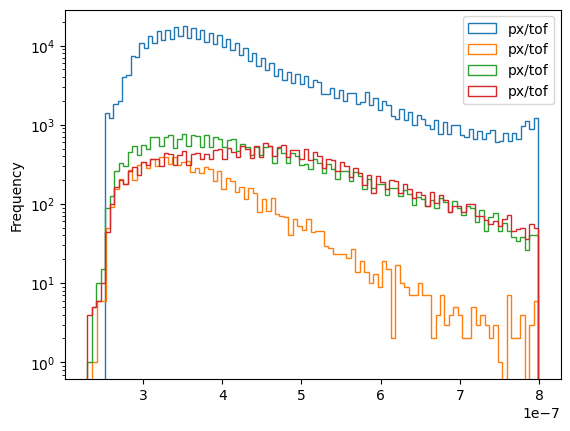

In [88]:
df_exp.query("0.25e-6<`px/tof`<0.8e-6").plot.hist(y="px/tof",bins=100,histtype="step",ax=gca())
d = results["blob_0.3_gain_10000"].dropna(subset="ph/id").query("0.2e-6<`px/tof`<0.8e-6")
d.plot.hist(y="px/tof",bins=100,histtype="step",ax=gca())
d = results["blob_0.7_gain_10000"].dropna(subset="ph/id").query("0.2e-6<`px/tof`<0.8e-6")
d.plot.hist(y="px/tof",bins=100,histtype="step",ax=gca())
d = results["blob_1.2_gain_10000"].dropna(subset="ph/id").query("0.2e-6<`px/tof`<0.8e-6")
d.plot.hist(y="px/tof",bins=100,histtype="step",ax=gca())
yscale("log")

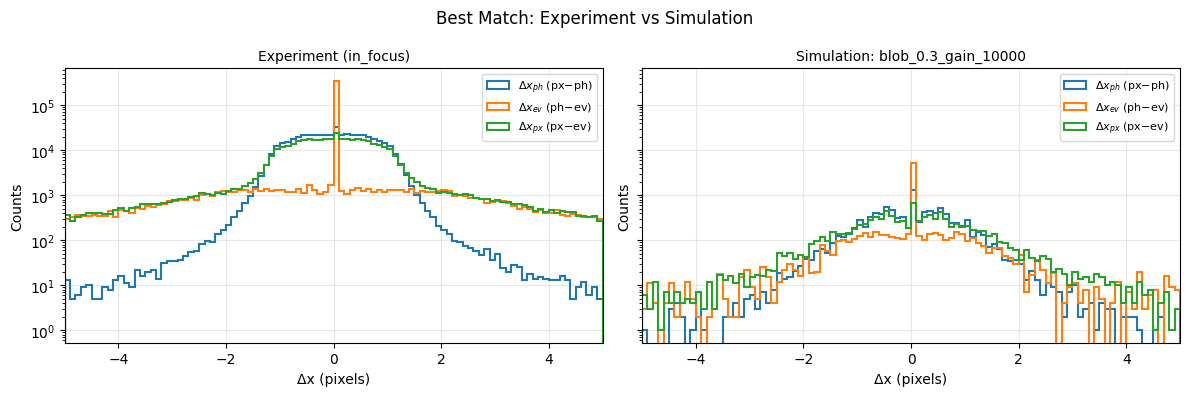

In [93]:
# Side-by-side: experiment vs best simulation
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_deltas(axes[0], df_exp,            title=f'Experiment (in_focus)')
plot_deltas(axes[1], results[best_sfx], title=f'Simulation: {best_sfx}')
fig.suptitle('Best Match: Experiment vs Simulation', fontsize=12)
plt.tight_layout()
plt.savefig(ARCHIVE / 'best_match_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Ranking by IQR Match

In [94]:
# IQR comparison table — all models ranked by closeness to experiment
exp_iqr = iqr_width(df_exp)
print(f'Experiment ph/Δx IQR: {exp_iqr:.3f} px')

widths = {name: iqr_width(df) for name, df in results.items()}
df_rank = pd.DataFrame([
    {'model': name, 'IQR(ph/Δx)': f'{v:.3f}', 'Δ_from_exp': f'{abs(v - exp_iqr):.3f}'}
    for name, v in sorted(widths.items(), key=lambda x: abs(x[1] - exp_iqr))
]).set_index('model')
display(df_rank)

Experiment ph/Δx IQR: 1.040 px


,IQR(ph/Δx),Δ_from_exp
model,,
blob_0.3_gain_10000,1.030,0.010
blob_0.3_gain_1000,1.050,0.010
blob_0.3_gain_10,1.000,0.040
blob_0.3_gain_100000,1.000,0.040
blob_1.2_gain_10,1.090,0.050
blob_1.2_gain_100,1.090,0.050
blob_0.3_gain_100,1.130,0.090
blob_1.2_gain_1000,1.130,0.090
blob_1.2_gain_10000,1.210,0.170


## 9. Statistics Comparison

In [95]:
def _cluster_std(df, group_col, value_cols):
    """Mean ± SEM of per-cluster std for each value column."""
    if group_col not in df.columns:
        return {c: (np.nan, np.nan) for c in value_cols}
    g = df.groupby(group_col)[[c for c in value_cols if c in df.columns]].std()
    return {c: (g[c].mean(), g[c].sem()) for c in g.columns}


def compute_stats(df):
    s = {}

    # ── counts ────────────────────────────────────────────────────────────────
    n_px = int(df['px/x'].notna().sum()) if 'px/x' in df.columns else 0
    n_ph = int(df['ph/n'].nunique())     if 'ph/n' in df.columns else np.nan
    n_ev = int(df['ev/n'].nunique())     if 'ev/n' in df.columns else np.nan
    s['n_pixels']  = n_px
    s['n_photons'] = n_ph
    s['n_events']  = n_ev
    s['px/ph']     = n_px / n_ph if n_ph else np.nan
    s['ph/ev']     = n_ph / n_ev if n_ev else np.nan

    # ── mean PSD (per unique event) ───────────────────────────────────────────
    if 'ev/n' in df.columns:
        ev = df.drop_duplicates('ev/n')
        for col in ['ev/PSD', 'ev/psd', 'PSD', 'psd']:
            if col in ev.columns:
                s['mean PSD'] = ev[col].mean()
                break
        else:
            s['mean PSD'] = np.nan

    # ── pixel spread *within* each photon cluster (mean ± SEM over clusters) ──
    px_cols = ['px/x', 'px/y', 'px/toa']
    if 'ph/n' in df.columns:
        for col, v in _cluster_std(df, 'ph/n', px_cols).items():
            s[f'{col} std/ph'] = v

    # ── photon spread *within* each event cluster ─────────────────────────────
    ph_cols = ['ph/x', 'ph/y', 'ph/toa']
    if 'ph/n' in df.columns and 'ev/n' in df.columns:
        ph_df = df.drop_duplicates('ph/n')
        for col, v in _cluster_std(ph_df, 'ev/n', ph_cols).items():
            s[f'{col} std/ev'] = v

    return s


# ── Collect stats ─────────────────────────────────────────────────────────────
all_stats = {'experiment': compute_stats(df_exp)}
for name, df in results.items():
    all_stats[name] = compute_stats(df)

# ── Split scalar vs tuple keys from first entry ───────────────────────────────
scalar_keys = ['n_pixels', 'n_photons', 'n_events', 'px/ph', 'ph/ev', 'mean PSD']
first_st    = next(iter(all_stats.values()))
tuple_keys  = [k for k, v in first_st.items() if isinstance(v, tuple)]

# Table 1 — counts, ratios, PSD
df_scalar = pd.DataFrame(
    {name: {k: v for k, v in st.items() if k in scalar_keys}
     for name, st in all_stats.items()}
).T
int_cols = ['n_pixels', 'n_photons', 'n_events']
for c in int_cols:
    if c in df_scalar:
        df_scalar[c] = df_scalar[c].astype('Int64')
print('── Counts, ratios, PSD ──────────────────────────────────────────────────')
display(df_scalar.style.format('{:.2f}', subset=[c for c in df_scalar.columns if c not in int_cols]))

# Table 2 — per-cluster stds as "mean ± SEM"
rows = {}
for name, st in all_stats.items():
    rows[name] = {k: f"{v[0]:.3f} ± {v[1]:.3f}" for k, v in st.items() if k in tuple_keys}
df_cluster = pd.DataFrame(rows).T
print('\n── Per-cluster spread (mean std ± SEM across clusters) ──────────────────')
display(df_cluster)

── Counts, ratios, PSD ──────────────────────────────────────────────────


,n_pixels,n_photons,n_events,px/ph,ph/ev,mean PSD
experiment,572805,12,13,47733.75,0.92,0.00
blob_0.3_gain_10,18261,13,8,1404.69,1.62,0.00
blob_0.3_gain_100,18261,14,8,1304.36,1.75,0.00
blob_0.3_gain_1000,18261,11,8,1660.09,1.38,0.00
blob_0.3_gain_10000,18261,12,8,1521.75,1.50,0.00
blob_0.3_gain_100000,18261,7,8,2608.71,0.88,0.00
blob_0.7_gain_10,126470,14,13,9033.57,1.08,0.00
blob_0.7_gain_100,126470,14,13,9033.57,1.08,0.00
blob_0.7_gain_1000,126470,14,12,9033.57,1.17,0.00
blob_0.7_gain_10000,126470,13,12,9728.46,1.08,0.00



── Per-cluster spread (mean std ± SEM across clusters) ──────────────────


,px/x std/ph,px/y std/ph,px/toa std/ph,ph/x std/ev,ph/y std/ev,ph/toa std/ev
experiment,61.085 ± 1.157,57.929 ± 0.930,0.582 ± 0.003,34.963 ± 11.600,35.789 ± 24.815,0.003 ± 0.003
blob_0.3_gain_10,66.127 ± 5.760,66.153 ± 5.533,0.009 ± 0.001,71.683 ± 2.956,74.843 ± 6.746,0.003 ± 0.002
blob_0.3_gain_100,62.107 ± 6.998,59.554 ± 6.927,0.008 ± 0.001,56.872 ± 10.362,50.355 ± 21.238,0.002 ± 0.000
blob_0.3_gain_1000,70.363 ± 1.698,71.685 ± 0.576,0.010 ± 0.000,67.120 ± 26.522,88.277 ± 10.374,0.001 ± 0.001
blob_0.3_gain_10000,67.901 ± 4.858,66.411 ± 3.523,0.009 ± 0.001,67.450 ± 27.707,90.491 ± 0.105,0.007 ± 0.005
blob_0.3_gain_100000,51.762 ± 11.888,47.422 ± 11.871,0.007 ± 0.002,10.871 ± 6.452,86.049 ± 17.012,0.006 ± 0.006
blob_0.7_gain_10,72.814 ± 1.536,70.549 ± 2.296,0.010 ± 0.000,70.901 ± 4.218,50.699 ± 37.075,0.000 ± 0.000
blob_0.7_gain_100,73.459 ± 1.372,70.441 ± 2.155,0.010 ± 0.000,38.877 ± 15.205,41.876 ± 20.662,0.000 ± 0.000
blob_0.7_gain_1000,68.207 ± 5.166,66.921 ± 5.191,0.009 ± 0.001,75.764 ± 39.001,82.538 ± 8.002,0.004 ± 0.004
blob_0.7_gain_10000,67.099 ± 5.525,65.606 ± 5.618,0.009 ± 0.001,73.578 ± 5.741,56.717 ± 22.548,0.002 ± 0.002


## 10. ToA Distributions — effect of `decay_time`

For each model and the experiment, plot the time-of-arrival differences within clusters:
- **Δtoa(ph−ev)**: per-photon `ph/toa − ev/toa` → spread of photon arrival times within an event  
- **Δtoa(px−ph)**: per-pixel `px/toa − ph/toa` → spread of pixel arrival times within a photon cluster

These distributions are directly shaped by `decay_time` (scintillator decay constant).

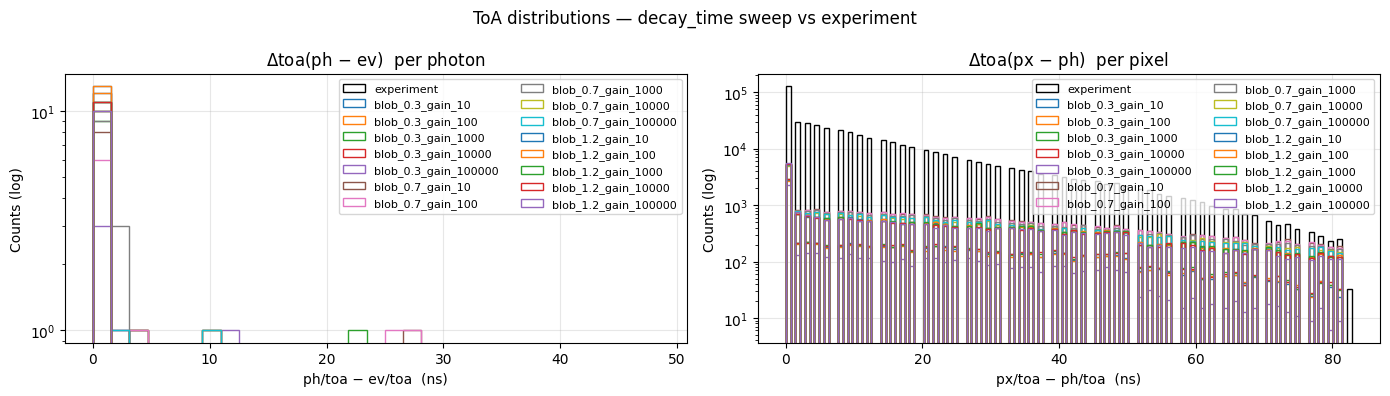

Saved: /work/nuclear/PTB/archive/openbeam_ptb/toa_comparison.png


In [96]:
def toa_diffs(df):
    """
    Return (dt_ph_ev, dt_px_ph) in nanoseconds.
    dt_ph_ev: ph/toa - ev/toa, deduplicated per photon.
    dt_px_ph: px/toa - ph/toa, one value per pixel row.
    """
    dt_ph_ev = dt_px_ph = None

    if 'ph/toa' in df.columns and 'ev/toa' in df.columns:
        ph_df = df.drop_duplicates('ph/n') if 'ph/n' in df.columns else df
        dt_ph_ev = (ph_df['ph/toa'] - ph_df['ev/toa']).dropna() * 1e9   # → ns

    if 'px/toa' in df.columns and 'ph/toa' in df.columns:
        dt_px_ph = (df['px/toa'] - df['ph/toa']).dropna() * 1e9          # → ns

    return dt_ph_ev, dt_px_ph


# ── Auto-range from experiment ────────────────────────────────────────────────
dt_exp_ph, dt_exp_px = toa_diffs(df_exp)

def _range(series, pct=99):
    lo, hi = np.nanpercentile(series, (100-pct)/2), np.nanpercentile(series, 100-(100-pct)/2)
    return lo, hi

ph_lo, ph_hi = _range(dt_exp_ph) if dt_exp_ph is not None else (-200, 200)
px_lo, px_hi = _range(dt_exp_px) if dt_exp_px is not None else (-200, 200)
bins_ph = np.arange(0,50,1.5625)
bins_px = np.linspace(px_lo, px_hi, 120)

# ── Plot ──────────────────────────────────────────────────────────────────────
all_items = [('experiment', df_exp)] + list(results.items())
colors    = ['black'] + [f'C{i}' for i in range(len(results))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for (name, df), color in zip(all_items, colors):
    dt_ph, dt_px = toa_diffs(df)
    lw = 2.0 if name == 'experiment' else 1.2
    ls = '-'  if name == 'experiment' else '--'
    if dt_ph is not None:
        axes[0].hist(dt_ph, bins=bins_ph, histtype='step',
                     color=color, lw=lw, ls=ls, label=name, log=True)
    if dt_px is not None:
        axes[1].hist(dt_px, bins=bins_px, histtype='step',
                     color=color, lw=lw, ls=ls, label=name, log=True)

for ax, title, xlabel in zip(
    axes,
    [r'$\Delta$toa(ph − ev)  per photon', r'$\Delta$toa(px − ph)  per pixel'],
    ['ph/toa − ev/toa  (ns)', 'px/toa − ph/toa  (ns)'],
):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Counts (log)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle('ToA distributions — decay_time sweep vs experiment', fontsize=12)
plt.tight_layout()
plt.savefig(ARCHIVE / 'toa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {ARCHIVE}/toa_comparison.png')

## Appendix: Quick single-run equivalent of the original CLI commands

```python
# empirun archive/pencilbeam2 --params ... --suffix in_focus --export
run_suffix(
    data_path=ARCHIVE,
    params_path=PARAMS_FILE,
    empir_search_dirs=EMPIR_DIRS,
    suffix='in_focus',
    export_pixels=True, export_photons=True, export_events=True,
    run_event2image=False,
)

# nea-assoc archive/pencilbeam2/in_focus --settings ...
analyser = nea.Analyse(
    data_folder=str(ARCHIVE / 'in_focus'),
    settings=str(PARAMS_FILE),
)
analyser.load()
analyser.associate()
```